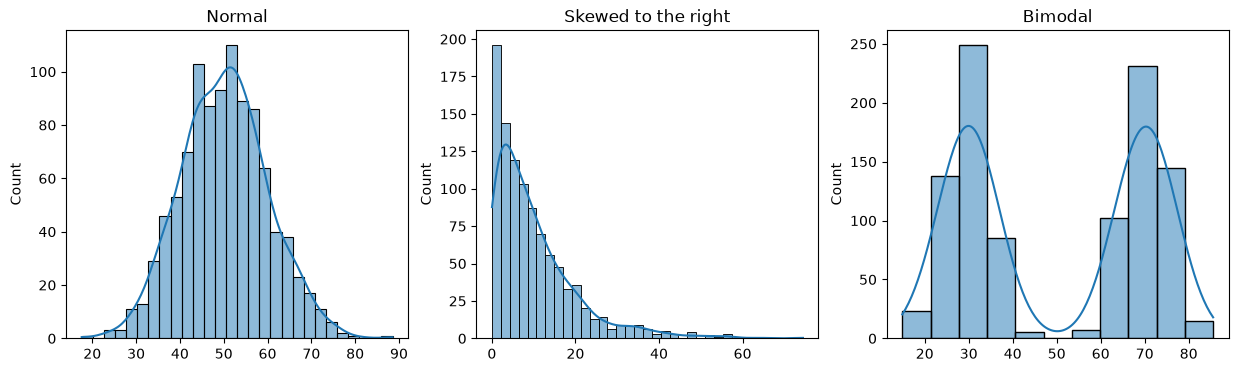

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

normal_dist = np.random.normal(loc=50, scale=10, size=1000)
skewed_dist = np.random.exponential(scale=10, size=1000) 
bimodal_dist = np.concatenate([
    np.random.normal(loc=30, scale=5, size=500),
    np.random.normal(loc=70, scale=5, size=500)])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(normal_dist, ax=axes[0], kde=True).set_title("Normal")
sns.histplot(skewed_dist, ax=axes[1], kde=True).set_title("Skewed to the right")
sns.histplot(bimodal_dist, ax=axes[2], kde=True).set_title("Bimodal")
plt.show()

In [8]:
def iqr_outliers(x):
    q1, q3 = np.percentile(x,[25,75])
    iqr = q3 - q1
    lower, upper = q1 - 3/2*iqr , q3 + 3/2*iqr
    return (x < lower) | (x > upper)

def zscore_outliers(x, threshold=3):
    z = (x - np.mean(x)) / np.std(x)
    return np.abs(z) > threshold

def modified_zscore_outliers(x, threshold=3.5):
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    if mad == 0:
        return np.zeros_like(x, dtype=bool)
    modified_z = 0.6745 * (x - median) / mad
    return np.abs(modified_z) > threshold

for name, dist in [("normal", normal_dist), ("skewed", skewed_dist), ("bimodal", bimodal_dist)]:
    print(f"\n{name}:")
    print("  IQR:", iqr_outliers(dist).sum())
    print("  Z-score:", zscore_outliers(dist).sum())
    print("  Modified Z-score:", modified_zscore_outliers(dist).sum())


normal:
  IQR: 8
  Z-score: 3
  Modified Z-score: 1

skewed:
  IQR: 55
  Z-score: 20
  Modified Z-score: 41

bimodal:
  IQR: 0
  Z-score: 0
  Modified Z-score: 0


In [3]:
import duckdb
duckdb.sql("CREATE VIEW duolingo_flagship AS SELECT * FROM read_csv_auto('../../data/duolingo_flagship_v4.csv')")
df = duckdb.sql("SELECT * FROM duolingo_flagship").df()

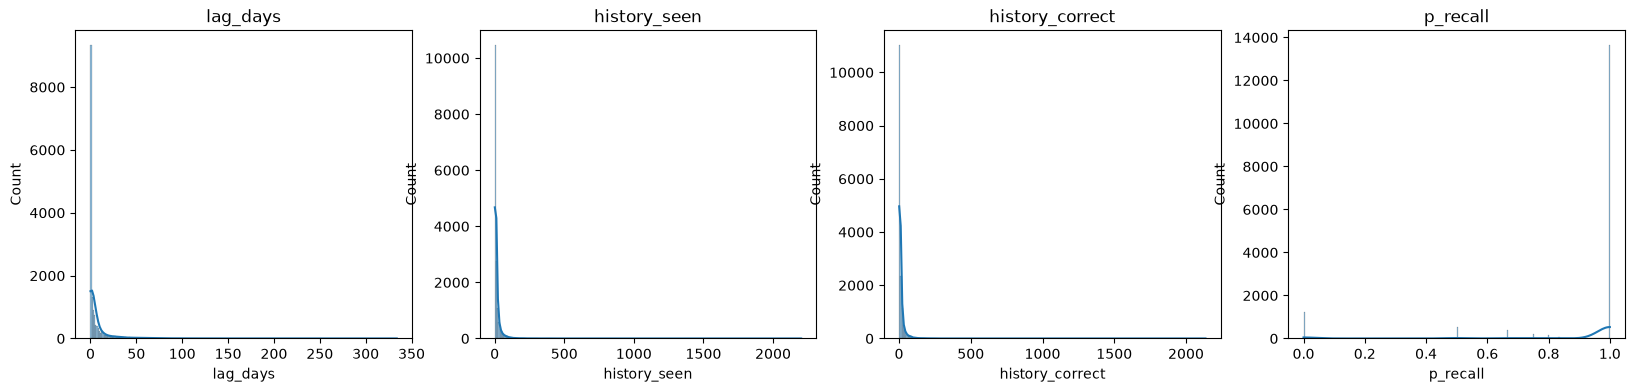

In [5]:
numeric_cols = ["lag_days", "history_seen", "history_correct", "p_recall"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], ax=axes[i], kde=True).set_title(col)
plt.show()

In [6]:
for col in numeric_cols:
    print(col, "skew:", df[col].skew())

lag_days skew: 6.420786745674379
history_seen skew: 20.802306569627618
history_correct skew: 22.07798788712513
p_recall skew: -2.576178264906604


In [9]:
for col in numeric_cols:
    x = df[col].values
    print(f"\n{col}:")
    print("  IQR:", iqr_outliers(x).sum())
    print("  Z-score:", zscore_outliers(x).sum())
    print("  Modified Z-score:", modified_zscore_outliers(x).sum())


lag_days:
  IQR: 2380
  Z-score: 321
  Modified Z-score: 3990

history_seen:
  IQR: 1788
  Z-score: 130
  Modified Z-score: 2710

history_correct:
  IQR: 1716
  Z-score: 124
  Modified Z-score: 1859

p_recall:
  IQR: 2739
  Z-score: 1240
  Modified Z-score: 0


## Observations

1. `p_recall` is heavily clumped at the median (75th percentile is already 1.0), so MAD collapses to 0 and modified z-score breaks down (divide by zero). IQR is the only reliable method here.

2. `history_seen` and `history_correct` are extremely skewed (skew > 20). Probably not an error.Likely some users just drill a word thousands of times ("power users"), while most don't. The high outlier counts reflect that real behavior, not bad data.

3. `lag_days` is also skewed but more moderately (skew 6.4). Most practice happens close together, a smaller number of sessions come back weeks or months later — consistent with users forgetting and re-practicing a word after a long gap.